# Wind Turbine Blade Defect Detection
**Dataset**: NordTank 586×371 (Dirt / Damage — YOLO format)  
**Model**: YOLOv8  
**Goal**: Detect surface defects on wind turbine blades via drone imagery

---
| Phase | Description |
|---|---|
| 1 | Environment Setup |
| 2 | EDA (Exploratory Data Analysis) |
| 3 | Data Preprocessing & Split |
| 4 | Model Training |
| 5 | Evaluation & Comparison |

In [16]:
import os

# ── Must be set BEFORE torch is imported ─────────────────────────────────────
# GPU 1 = NVIDIA TITAN RTX (24 GB) — hardcoded to avoid late-binding issue
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch

print("=" * 50)
print("GPU CHECK")
print("=" * 50)

if not torch.cuda.is_available():
    print("⚠  No CUDA GPU detected")
else:
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        vram = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  GPU {i}: {name}  ({vram:.1f} GB VRAM)")

    name = torch.cuda.get_device_name(0)
    if "titan" in name.lower():
        print("\n✓  Titan RTX active as device 0 — ready for training")
    else:
        print(f"\n⚠  Expected Titan RTX but got: {name}")
        print("   Change CUDA_VISIBLE_DEVICES above to the correct GPU index")

print("=" * 50)

GPU CHECK
  GPU 0: NVIDIA TITAN RTX  (24.0 GB VRAM)

✓  Titan RTX active as device 0 — ready for training


## Phase 1 — Environment Setup

In [17]:
import os, sys
from pathlib import Path

# ── 1. Install / verify packages ────────────────────────────────────────────
os.system("pip install 'numpy<2' ultralytics opencv-python pandas matplotlib seaborn PyYAML tqdm scikit-learn -q")

import numpy as np
import pandas as pd
import cv2
import matplotlib
import seaborn as sns
import yaml
import torch
from ultralytics import YOLO

print("Package versions")
print(f"  numpy      : {np.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  opencv     : {cv2.__version__}")
print(f"  matplotlib : {matplotlib.__version__}")
print(f"  torch      : {torch.__version__}")

# ── 2. Dataset path ─────────────────────────────────────────────────────────
DATA_ROOT = Path("./data/NordTank586x371")
IMG_DIR   = DATA_ROOT / "images"
LBL_DIR   = DATA_ROOT / "labels"

assert DATA_ROOT.exists(), f"Dataset not found: {DATA_ROOT}"
assert IMG_DIR.exists()  , f"images folder missing"
assert LBL_DIR.exists()  , f"labels folder missing"

print(f"\nDataset root : {DATA_ROOT.resolve()}")
print(f"  images     : {len(list(IMG_DIR.iterdir()))}")
print(f"  labels     : {len(list(LBL_DIR.iterdir()))}")

# ── 3. Output directory ──────────────────────────────────────────────────────
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
print(f"\nOutput dir   : {OUT_DIR.resolve()}")

# ── 4. GPU check ─────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    DEVICE = 0
else:
    print("  No GPU — using CPU")
    DEVICE = "cpu"

print("\nPhase 1 complete.")

Package versions
  numpy      : 1.26.4
  pandas     : 3.0.3
  opencv     : 4.11.0
  matplotlib : 3.10.9
  torch      : 2.12.0+cu130

Dataset root : /home/jhyun/Root/VScode/AIFFEL/Hackathon/data/NordTank586x371
  images     : 13470
  labels     : 2996

Output dir   : /home/jhyun/Root/VScode/AIFFEL/Hackathon/outputs
  GPU 0: NVIDIA TITAN RTX

Phase 1 complete.


## Phase 2 — Exploratory Data Analysis (EDA)

In [18]:
import warnings, random
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")

CLASS_NAMES = {0: "Dirt", 1: "Damage"}
CLASS_COLORS = {0: "#2196F3", 1: "#FF5722"}   # Blue / Orange-red

# ── 1. Build file lists ──────────────────────────────────────────────────────
img_exts = {".jpg", ".jpeg", ".png", ".JPG"}

all_images = {p.stem: p for p in IMG_DIR.iterdir() if p.suffix in img_exts}
all_labels = {p.stem: p for p in LBL_DIR.iterdir() if p.suffix == ".txt"}

labeled_stems   = sorted(all_images.keys() & all_labels.keys())
unlabeled_stems = sorted(all_images.keys() - all_labels.keys())

print(f"Total images         : {len(all_images):>6}")
print(f"  w/ annotations     : {len(labeled_stems):>6}")
print(f"  w/o annotations    : {len(unlabeled_stems):>6}  (normal / no defect)")
print(f"Label files          : {len(all_labels):>6}")

# ── 2. Parse all bounding boxes ──────────────────────────────────────────────
records = []
for stem in tqdm(labeled_stems, desc="Parsing labels"):
    with open(all_labels[stem]) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
                records.append({"stem": stem, "class_id": cls,
                                 "x_center": xc, "y_center": yc,
                                 "w": w, "h": h, "area": w * h})

df = pd.DataFrame(records)
print(f"\nTotal bounding boxes : {len(df):>6}")
print(df["class_id"].value_counts().rename(CLASS_NAMES).to_string())

Total images         :  13470
  w/ annotations     :   2995
  w/o annotations    :  10475  (normal / no defect)
Label files          :   2996


Parsing labels: 100%|██████████| 2995/2995 [00:00<00:00, 56353.05it/s]


Total bounding boxes :   9351
class_id
Damage    8770
Dirt       581


In [19]:
# ── 3. Per-image annotation count distribution ───────────────────────────────
boxes_per_img = df.groupby("stem").size()

print("Annotations per labeled image")
print(boxes_per_img.describe().to_string())

# ── 4. Bounding-box size stats by class ──────────────────────────────────────
print("\nBounding-box statistics by class")
print(df.groupby("class_id")[["w", "h", "area"]]
        .describe().round(4)
        .rename(index=CLASS_NAMES))

Annotations per labeled image
count    2995.000000
mean        3.122204
std         3.422063
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        37.000000

Bounding-box statistics by class
               w                                                            h  \
           count    mean     std     min     25%     50%     75%  max   count   
class_id                                                                        
Dirt       581.0  0.5089  0.3225  0.0085  0.2679  0.4352  0.9829  1.0   581.0   
Damage    8770.0  0.0512  0.0629  0.0000  0.0171  0.0307  0.0597  1.0  8770.0   

                  ...                 area                                  \
            mean  ...     75%  max   count    mean     std     min     25%   
class_id          ...                                                        
Dirt      0.6392  ...  0.9982  1.0   581.0  0.3022  0.1738  0.0002  0.1576   
Damage    0.0758  ...  0.0943  1.0  8770.0  0.0070

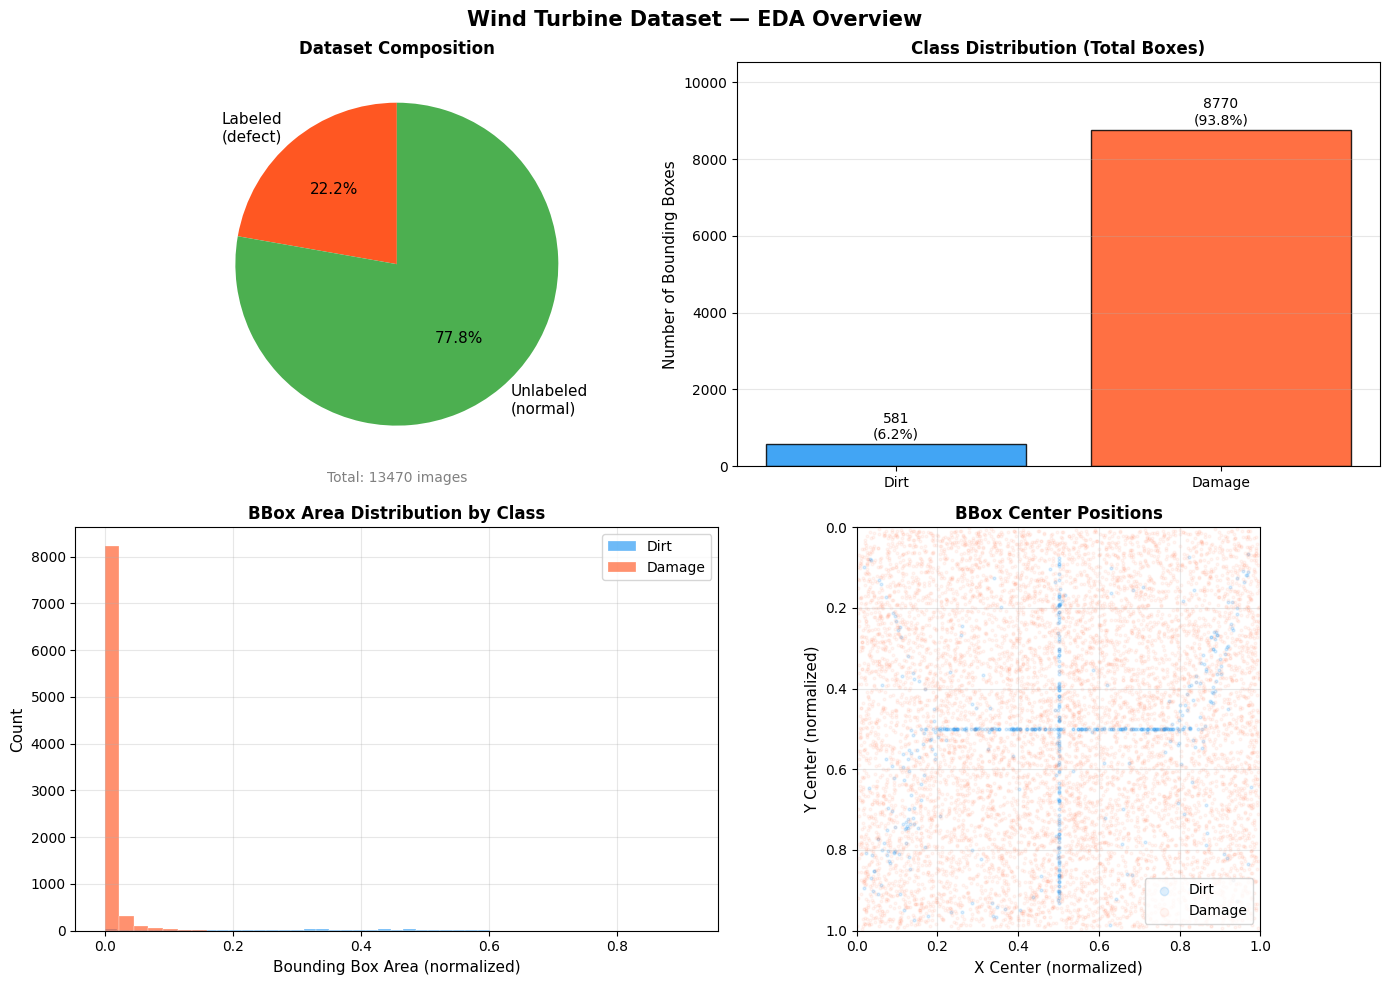

Saved → outputs/phase2_eda_overview.png


In [20]:
# ── 5. Visualisation (4-panel overview) ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Wind Turbine Dataset — EDA Overview", fontsize=15, fontweight="bold")

# ① Dataset composition
ax = axes[0, 0]
labels_pie  = ["Labeled\n(defect)", "Unlabeled\n(normal)"]
sizes_pie   = [len(labeled_stems), len(unlabeled_stems)]
colors_pie  = ["#FF5722", "#4CAF50"]
wedges, texts, autotexts = ax.pie(
    sizes_pie, labels=labels_pie, colors=colors_pie,
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 11})
ax.set_title("Dataset Composition", fontsize=12, fontweight="bold")
ax.text(0, -1.35, f"Total: {len(all_images)} images",
        ha="center", fontsize=10, color="gray")

# ② Class distribution (bounding boxes)
ax = axes[0, 1]
class_counts = df["class_id"].value_counts().sort_index()
bar_colors   = [CLASS_COLORS[i] for i in class_counts.index]
bars = ax.bar([CLASS_NAMES[i] for i in class_counts.index],
              class_counts.values, color=bar_colors, alpha=0.85, edgecolor="black")
for bar, cnt in zip(bars, class_counts.values):
    pct = cnt / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{cnt}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of Bounding Boxes", fontsize=11)
ax.set_title("Class Distribution (Total Boxes)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, class_counts.max() * 1.2)

# ③ BBox area distribution by class
ax = axes[1, 0]
for cls_id, name in CLASS_NAMES.items():
    data = df[df["class_id"] == cls_id]["area"]
    ax.hist(data, bins=40, alpha=0.65, label=name,
            color=CLASS_COLORS[cls_id], edgecolor="white", linewidth=0.3)
ax.set_xlabel("Bounding Box Area (normalized)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("BBox Area Distribution by Class", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ④ BBox center position heatmap
ax = axes[1, 1]
ax.scatter(df[df["class_id"]==0]["x_center"],
           df[df["class_id"]==0]["y_center"],
           alpha=0.15, s=4, color=CLASS_COLORS[0], label="Dirt")
ax.scatter(df[df["class_id"]==1]["x_center"],
           df[df["class_id"]==1]["y_center"],
           alpha=0.05, s=4, color=CLASS_COLORS[1], label="Damage")
ax.set_xlim(0, 1); ax.set_ylim(1, 0)   # image coords: y=0 at top
ax.set_xlabel("X Center (normalized)", fontsize=11)
ax.set_ylabel("Y Center (normalized)", fontsize=11)
ax.set_title("BBox Center Positions", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, markerscale=3)
ax.grid(alpha=0.3)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(OUT_DIR / "phase2_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/phase2_eda_overview.png")

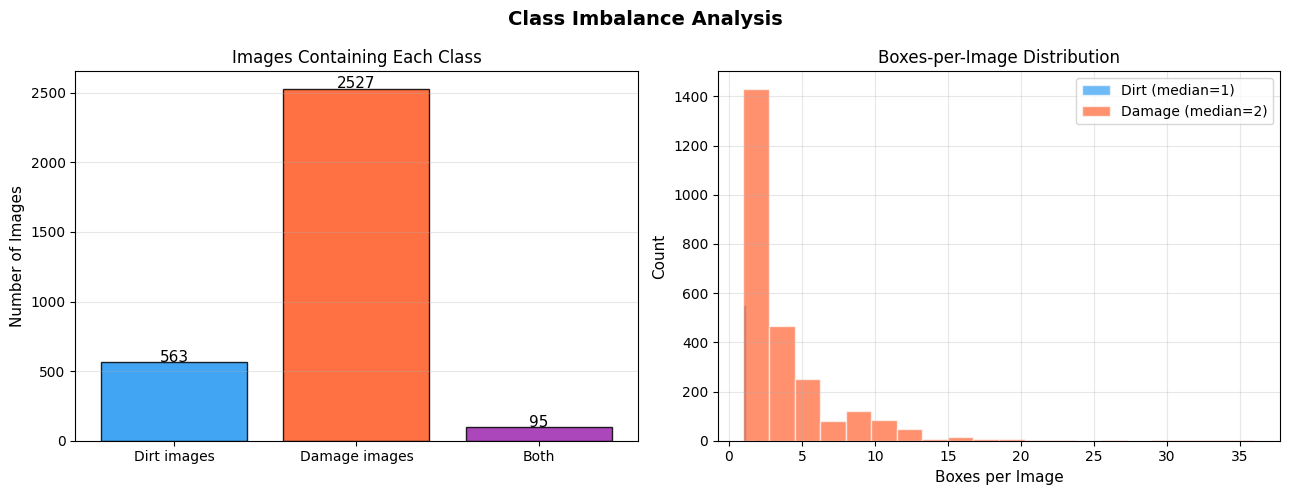

Damage / Dirt box ratio : 15.1x  →  significant class imbalance
Saved → outputs/phase2_imbalance.png


In [21]:
# ── 6. Class imbalance deep-dive ─────────────────────────────────────────────
dirt_count   = int((df["class_id"] == 0).sum())
damage_count = int((df["class_id"] == 1).sum())
ratio        = damage_count / max(dirt_count, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Imbalance Analysis", fontsize=14, fontweight="bold")

# Left: images that contain each class
ax = axes[0]
only_dirt   = df[df["class_id"]==0]["stem"].nunique()
only_damage = df[df["class_id"]==1]["stem"].nunique()
both_stems  = set(df[df["class_id"]==0]["stem"]) & set(df[df["class_id"]==1]["stem"])

bars = ax.bar(["Dirt images", "Damage images", "Both"],
              [only_dirt, only_damage, len(both_stems)],
              color=[CLASS_COLORS[0], CLASS_COLORS[1], "#9C27B0"],
              alpha=0.85, edgecolor="black")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_title("Images Containing Each Class", fontsize=12)
ax.grid(axis="y", alpha=0.3)

# Right: per-image box count distribution
ax = axes[1]
for cls_id, name in CLASS_NAMES.items():
    per_img = df[df["class_id"]==cls_id].groupby("stem").size()
    ax.hist(per_img, bins=20, alpha=0.65, label=f"{name} (median={per_img.median():.0f})",
            color=CLASS_COLORS[cls_id], edgecolor="white")
ax.set_xlabel("Boxes per Image", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Boxes-per-Image Distribution", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "phase2_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Damage / Dirt box ratio : {ratio:.1f}x  →  significant class imbalance")
print(f"Saved → {OUT_DIR}/phase2_imbalance.png")

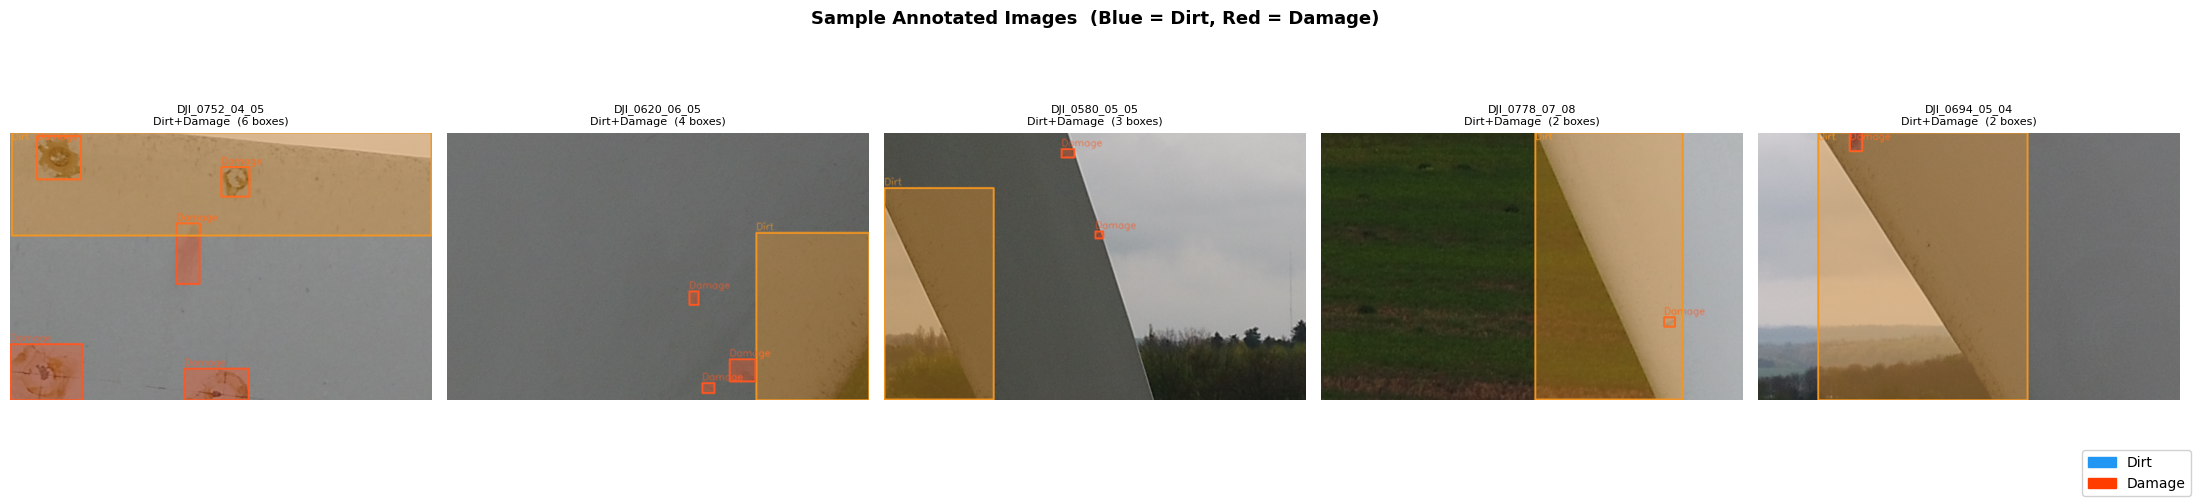

Saved → outputs/phase2_sample_images.png


In [22]:
# ── 7. Sample images with bounding boxes ────────────────────────────────────

def draw_boxes(stem, alpha=0.35):
    """Return RGB image with YOLO boxes drawn."""
    img_path = all_images[stem]
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    H, W = img.shape[:2]
    overlay = img.copy()

    with open(all_labels[stem]) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])
            x0 = int((xc - bw/2) * W)
            y0 = int((yc - bh/2) * H)
            x1 = int((xc + bw/2) * W)
            y1 = int((yc + bh/2) * H)
            bgr = (33, 150, 243) if cls_id == 0 else (34, 87, 255)   # Blue / Red
            cv2.rectangle(overlay, (x0, y0), (x1, y1), bgr, -1)
            cv2.rectangle(img,     (x0, y0), (x1, y1), bgr,  2)
            label = CLASS_NAMES.get(cls_id, str(cls_id))
            cv2.putText(img, label, (x0, max(y0-4, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, bgr, 1, cv2.LINE_AA)

    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


random.seed(42)

# Pick 5 images: prioritise ones with BOTH classes
mixed = sorted(both_stems)  
sample_stems = (random.sample(mixed, min(5, len(mixed)))
                if mixed else random.sample(labeled_stems, 5))

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Sample Annotated Images  (Blue = Dirt, Red = Damage)",
             fontsize=13, fontweight="bold")

for ax, stem in zip(axes, sample_stems):
    rgb = draw_boxes(stem)
    if rgb is not None:
        ax.imshow(rgb)
    n_boxes = df[df["stem"] == stem].shape[0]
    cls_str = "+".join(CLASS_NAMES[c] for c in sorted(df[df["stem"]==stem]["class_id"].unique()))
    ax.set_title(f"{stem[:18]}\n{cls_str}  ({n_boxes} boxes)", fontsize=8)
    ax.axis("off")

# Legend
legend_patches = [mpatches.Patch(color="#2196F3", label="Dirt"),
                  mpatches.Patch(color="#FF3D00", label="Damage")]
fig.legend(handles=legend_patches, loc="lower right",
           fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / "phase2_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/phase2_sample_images.png")

In [23]:
# ── 8. EDA summary ───────────────────────────────────────────────────────────
print("=" * 65)
print("EDA SUMMARY")
print("=" * 65)
print(f"  Total images            : {len(all_images)}")
print(f"  Labeled (defect)        : {len(labeled_stems)}  ({len(labeled_stems)/len(all_images)*100:.1f}%)")
print(f"  Unlabeled (normal)      : {len(unlabeled_stems)}  ({len(unlabeled_stems)/len(all_images)*100:.1f}%)")
print(f"  Total bounding boxes    : {len(df)}")
print(f"    Dirt   (class 0)      : {dirt_count}  ({dirt_count/len(df)*100:.1f}%)")
print(f"    Damage (class 1)      : {damage_count}  ({damage_count/len(df)*100:.1f}%)")
print(f"  Damage/Dirt ratio       : {ratio:.1f}x  ← severe imbalance")
print(f"  Avg boxes / labeled img : {len(df)/len(labeled_stems):.2f}")
print()
print("Key observations:")
print(f"  1. Only {len(labeled_stems)/len(all_images)*100:.0f}% of images contain defects — strong class imbalance at image level")
print(f"  2. Damage annotations are {ratio:.0f}x more frequent than Dirt")
print(f"  3. Defect regions are small (avg area ≈ {df['area'].mean()*100:.2f}% of image)")
print(f"  4. {len(both_stems)} images contain both Dirt and Damage simultaneously")
print()
print("Action for Phase 3:")
print("  - 80/20 train/val split on labeled images")
print("  - Address Damage/Dirt imbalance via augmentation or class weights")
print("=" * 65)

EDA SUMMARY
  Total images            : 13470
  Labeled (defect)        : 2995  (22.2%)
  Unlabeled (normal)      : 10475  (77.8%)
  Total bounding boxes    : 9351
    Dirt   (class 0)      : 581  (6.2%)
    Damage (class 1)      : 8770  (93.8%)
  Damage/Dirt ratio       : 15.1x  ← severe imbalance
  Avg boxes / labeled img : 3.12

Key observations:
  1. Only 22% of images contain defects — strong class imbalance at image level
  2. Damage annotations are 15x more frequent than Dirt
  3. Defect regions are small (avg area ≈ 2.54% of image)
  4. 95 images contain both Dirt and Damage simultaneously

Action for Phase 3:
  - 80/20 train/val split on labeled images
  - Address Damage/Dirt imbalance via augmentation or class weights


## Phase 3 — Data Preprocessing & Train/Val Split

In [24]:
import os, shutil, random
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import yaml

random.seed(42)
np.random.seed(42)

SRC_IMG = Path("./data/NordTank586x371/images")
SRC_LBL = Path("./data/NordTank586x371/labels")

img_exts        = {".jpg", ".jpeg", ".png", ".JPG"}
all_imgs        = {p.stem: p for p in SRC_IMG.iterdir() if p.suffix in img_exts}
all_lbls        = {p.stem: p for p in SRC_LBL.iterdir() if p.suffix == ".txt"}
labeled_stems   = sorted(all_imgs.keys() & all_lbls.keys())
unlabeled_stems = sorted(all_imgs.keys() - all_lbls.keys())

dirt_stems = []
for stem in labeled_stems:
    with open(all_lbls[stem]) as f:
        classes = {int(l.split()[0]) for l in f if l.strip()}
    if 0 in classes:
        dirt_stems.append(stem)

all_stems = labeled_stems + unlabeled_stems
train_stems, val_stems = train_test_split(all_stems, test_size=0.2, random_state=42)
train_set = set(train_stems)

print(f"전체 이미지 : {len(all_imgs)}  |  정상 : {len(unlabeled_stems)}  |  라벨 : {len(labeled_stems)}  |  Dirt : {len(dirt_stems)}")
print(f"Train : {len(train_stems)}  |  Val : {len(val_stems)}")

# ── 공통 함수 ────────────────────────────────────────────────────────────────
def make_dirs(out):
    for split in ["train", "val"]:
        (out / "images" / split).mkdir(parents=True, exist_ok=True)
        (out / "labels" / split).mkdir(parents=True, exist_ok=True)

def copy_pair(stem, split, out, new_stem=None):
    img_src  = all_imgs[stem]
    dst_stem = new_stem or stem
    shutil.copy2(img_src, out / "images" / split / (dst_stem + img_src.suffix))
    lbl_dst = out / "labels" / split / (dst_stem + ".txt")
    if stem in all_lbls:
        shutil.copy2(all_lbls[stem], lbl_dst)
    else:
        lbl_dst.touch()

def augment_image(img):
    ops = []
    if random.random() > 0.5: img = cv2.flip(img, 1); ops.append("fliplr")
    if random.random() > 0.5: img = cv2.flip(img, 0); ops.append("flipud")
    img = cv2.convertScaleAbs(img, alpha=random.uniform(0.7, 1.3), beta=random.randint(-30, 30))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:,:,1] = np.clip(hsv[:,:,1] * random.uniform(0.7, 1.3), 0, 255)
    img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return img, ops

def flip_label(line, ops):
    p = line.strip().split()
    if len(p) != 5: return line
    cls, xc, yc, w, h = int(p[0]), *map(float, p[1:])
    if "fliplr" in ops: xc = 1.0 - xc
    if "flipud" in ops: yc = 1.0 - yc
    return f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n"

def add_dirt_aug(train_dirt, out, times=8):
    for stem in tqdm(train_dirt, desc="  Dirt aug"):
        img = cv2.imread(str(all_imgs[stem]))
        if img is None: continue
        with open(all_lbls[stem]) as f: lines = f.readlines()
        for i in range(times):
            aug_img, ops = augment_image(img.copy())
            new_stem = f"{stem}_aug{i}"
            cv2.imwrite(str(out / "images" / "train" / (new_stem + all_imgs[stem].suffix)), aug_img)
            with open(out / "labels" / "train" / (new_stem + ".txt"), "w") as f:
                for line in lines: f.write(flip_label(line, ops))

def write_yaml(out, name):
    cfg = {"path": str(out.resolve()), "train": "images/train", "val": "images/val",
           "nc": 2, "names": {0: "Dirt", 1: "Damage"}}
    with open(out / "dataset.yaml", "w") as f:
        yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

def report(out):
    for split in ["train", "val"]:
        n = len(list((out / "images" / split).iterdir()))
        aug = len([f for f in (out / "images" / split).iterdir() if "_aug" in f.stem])
        print(f"  {split}: {n}장  (원본 {n-aug} + 증강 {aug})")

# make_normal_subsample: normal 수 제한 데이터셋 생성 helper.
# 초기 탐색(subsample·normal3000~6000)에 사용했으나, val이 실험마다 재샘플링되어
# 시험지가 달라지는 문제로 최종 비교에서 제외 → data/_archive_normal_limited/ 보관.
# 재현이 필요하면 아래 함수로 다시 생성 가능 (현재 파이프라인에서는 호출하지 않음).
def make_normal_subsample(name, normal_limit, with_dirt_aug=False):
    out = Path(f"./data/{name}")
    if (out / "dataset.yaml").exists():
        print(f"[{name}] 이미 존재 — 건너뜀")
        return
    normal_train = [s for s in train_stems if s in set(unlabeled_stems)]
    normal_val   = [s for s in val_stems   if s in set(unlabeled_stems)]
    label_train  = [s for s in train_stems if s in set(labeled_stems)]
    label_val    = [s for s in val_stems   if s in set(labeled_stems)]
    random.seed(42)
    sub_n_train  = random.sample(normal_train, min(int(normal_limit * 0.8), len(normal_train)))
    sub_n_val    = random.sample(normal_val,   min(int(normal_limit * 0.2), len(normal_val)))
    make_dirs(out)
    for s in tqdm(label_train + sub_n_train, desc=f"[{name}] train"): copy_pair(s, "train", out)
    for s in tqdm(label_val   + sub_n_val,   desc=f"[{name}] val  "): copy_pair(s, "val",   out)
    if with_dirt_aug:
        add_dirt_aug([s for s in dirt_stems if s in train_set], out, times=8)
    write_yaml(out, name)
    print(f"[{name}] 완료  (정상 train={len(sub_n_train)}, val={len(sub_n_val)})"); report(out)

# ── 1. labeled-only (모델 선정용) ─────────────────────────────────────────────
NAME1 = "dataset_yolo"
OUT1  = Path(f"./data/{NAME1}")
if not (OUT1 / "dataset.yaml").exists():
    labeled_train, labeled_val = train_test_split(labeled_stems, test_size=0.2, random_state=42)
    make_dirs(OUT1)
    for s in tqdm(labeled_train, desc=f"[{NAME1}] train"): copy_pair(s, "train", OUT1)
    for s in tqdm(labeled_val,   desc=f"[{NAME1}] val  "): copy_pair(s, "val",   OUT1)
    write_yaml(OUT1, NAME1)
    print(f"[{NAME1}] 생성 완료"); report(OUT1)
else:
    print(f"[{NAME1}] 이미 존재 — 건너뜀")

# ── 2. full (전체 데이터, 증강 없음) — 베이스라인 ────────────────────────────
NAME2 = "dataset_yolo_full"
OUT2  = Path(f"./data/{NAME2}")
if not (OUT2 / "dataset.yaml").exists():
    make_dirs(OUT2)
    for s in tqdm(train_stems, desc=f"[{NAME2}] train"): copy_pair(s, "train", OUT2)
    for s in tqdm(val_stems,   desc=f"[{NAME2}] val  "): copy_pair(s, "val",   OUT2)
    write_yaml(OUT2, NAME2)
    print(f"[{NAME2}] 생성 완료"); report(OUT2)
else:
    print(f"[{NAME2}] 이미 존재 — 건너뜀")

# ── 3. full_aug (전체 데이터 + Dirt ×8 증강) ─────────────────────────────────
NAME3 = "dataset_yolo_full_aug"
OUT3  = Path(f"./data/{NAME3}")
if not (OUT3 / "dataset.yaml").exists():
    make_dirs(OUT3)
    for s in tqdm(train_stems, desc=f"[{NAME3}] train"): copy_pair(s, "train", OUT3)
    for s in tqdm(val_stems,   desc=f"[{NAME3}] val  "): copy_pair(s, "val",   OUT3)
    add_dirt_aug([s for s in dirt_stems if s in train_set], OUT3, times=8)
    write_yaml(OUT3, NAME3)
    print(f"[{NAME3}] 생성 완료"); report(OUT3)
else:
    print(f"[{NAME3}] 이미 존재 — 건너뜀")

# 참고: full_blade / full_aug_blade 는 blade 외부 데이터(crack→Damage 리맵핑)를
#       train에만 추가하는 별도 단계에서 생성. val은 full과 동일(2,694장) 유지.

print("\n=== Phase 3 완료 (full 계열 + 모델 선정 데이터) ===")
datasets = [
    ("dataset_yolo",          Path("./data/dataset_yolo")),
    ("dataset_yolo_full",     Path("./data/dataset_yolo_full")),
    ("dataset_yolo_full_aug", Path("./data/dataset_yolo_full_aug")),
]
for name, out in datasets:
    n_train = len(list((out / "images" / "train").iterdir()))
    n_val   = len(list((out / "images" / "val").iterdir()))
    print(f"  {name:<28} train={n_train:>6}  val={n_val:>5}")

전체 이미지 : 13470  |  정상 : 10475  |  라벨 : 2995  |  Dirt : 563
Train : 10776  |  Val : 2694
[dataset_yolo] 이미 존재 — 건너뜀
[dataset_yolo_full] 이미 존재 — 건너뜀
[dataset_yolo_full_aug] 이미 존재 — 건너뜀

=== Phase 3 완료 (full 계열 + 모델 선정 데이터) ===
  dataset_yolo                 train=  2396  val=  599
  dataset_yolo_full            train= 10776  val= 2694
  dataset_yolo_full_aug        train= 14400  val= 2694


### Phase 3-2 — Blade 외부 데이터 추가 (full_blade / full_aug_blade)

Wind Turbine Blade v7i(Roboflow) train 1,474장을 `crack → Damage(class 1)` 리맵 후 train에만 병합.
valid/test(620장)는 도메인(384×384·다른 터빈) 혼재로 미사용, **val은 full과 동일(2,694장)** 유지.

| 데이터셋 | train | val |
|---|---|---|
| dataset_yolo_full_blade | 10,776 + 1,474 = 12,250 | 2,694 |
| dataset_yolo_full_aug_blade | 14,400 + 1,474 = 15,874 | 2,694 |

In [25]:
import zipfile

# ── blade 외부 데이터 (Wind Turbine Blade v7i) → full_blade / full_aug_blade ──
# 클래스: crack(nc=1) → Damage(class 1)로 리맵. train 1,474장만 사용
# (valid 415 + test 205 = 620장은 도메인(384×384·다른 터빈) 혼재 방지로 미사용).
# val은 full과 동일(2,694장) 유지 → full 계열끼리 동일 시험지로 공정 비교.
BLADE_ZIP = Path("./data/Wind turbine blade.v7i.yolov8.zip")
BLADE_SRC = Path("./data/_blade_src")   # zip 해제 스테이징

def prepare_blade_src():
    """blade zip의 train split만 해제."""
    if (BLADE_SRC / "train" / "images").exists():
        return
    with zipfile.ZipFile(BLADE_ZIP) as z:
        for m in z.namelist():
            if (m.startswith("train/images/") or m.startswith("train/labels/")) and not m.endswith("/"):
                z.extract(m, BLADE_SRC)
    print(f"[blade] train split 해제 완료 → {BLADE_SRC}")

def add_blade_to_train(out):
    """blade train 이미지+라벨을 out/…/train 에 병합. crack(0) → Damage(1) 리맵."""
    b_img = BLADE_SRC / "train" / "images"
    b_lbl = BLADE_SRC / "train" / "labels"
    n = 0
    for img in b_img.iterdir():
        shutil.copy2(img, out / "images" / "train" / img.name)
        src_lbl = b_lbl / (img.stem + ".txt")
        lines_out = []
        if src_lbl.exists():
            with open(src_lbl) as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) == 5:
                        p[0] = "1"   # crack(0) → Damage(1)
                        lines_out.append(" ".join(p) + "\n")
        with open(out / "labels" / "train" / (img.stem + ".txt"), "w") as f:
            f.writelines(lines_out)
        n += 1
    return n

def copy_dataset(src, dst):
    """기존 데이터셋(train+val) 전체 복제."""
    make_dirs(dst)
    for split in ["train", "val"]:
        for sub in ["images", "labels"]:
            for p in (src / sub / split).iterdir():
                shutil.copy2(p, dst / sub / split / p.name)

def make_blade_variant(base_name, out_name):
    out  = Path(f"./data/{out_name}")
    base = Path(f"./data/{base_name}")
    if (out / "dataset.yaml").exists():
        print(f"[{out_name}] 이미 존재 — 건너뜀"); return
    prepare_blade_src()
    print(f"[{out_name}] {base_name} 복제 중...")
    copy_dataset(base, out)
    added = add_blade_to_train(out)
    write_yaml(out, out_name)
    print(f"[{out_name}] 완료 — blade {added}장 train 추가"); report(out)

# full + blade
make_blade_variant("dataset_yolo_full",     "dataset_yolo_full_blade")
# full_aug + blade
make_blade_variant("dataset_yolo_full_aug", "dataset_yolo_full_aug_blade")

print("\n=== Phase 3 전체 데이터셋 (full 계열 + 모델 선정) ===")
datasets = [
    ("dataset_yolo",               Path("./data/dataset_yolo")),
    ("dataset_yolo_full",          Path("./data/dataset_yolo_full")),
    ("dataset_yolo_full_aug",      Path("./data/dataset_yolo_full_aug")),
    ("dataset_yolo_full_blade",    Path("./data/dataset_yolo_full_blade")),
    ("dataset_yolo_full_aug_blade",Path("./data/dataset_yolo_full_aug_blade")),
]
for name, out in datasets:
    n_train = len(list((out / "images" / "train").iterdir()))
    n_val   = len(list((out / "images" / "val").iterdir()))
    print(f"  {name:<30} train={n_train:>6}  val={n_val:>5}")

[dataset_yolo_full_blade] 이미 존재 — 건너뜀
[dataset_yolo_full_aug_blade] 이미 존재 — 건너뜀

=== Phase 3 전체 데이터셋 (full 계열 + 모델 선정) ===
  dataset_yolo                   train=  2396  val=  599
  dataset_yolo_full              train= 10776  val= 2694
  dataset_yolo_full_aug          train= 14400  val= 2694
  dataset_yolo_full_blade        train= 12250  val= 2694
  dataset_yolo_full_aug_blade    train= 15874  val= 2694


## Phase 4 — YOLOv8 Model Training

In [26]:
import os
from ultralytics import YOLO
from pathlib import Path
import torch

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
torch.cuda.empty_cache()
TRAIN_DEVICE = 0
OUT_BASE     = Path("./runs").resolve()   # 절대경로 — ultralytics prefix 방지
YAML_LABELED = "./data/dataset_yolo/dataset.yaml"
print(f"OUT_BASE : {OUT_BASE}")
print(f"Active device : {torch.cuda.get_device_name(0)}  ({torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB)")

def find_best_pt(out_base, name):
    candidates = sorted(out_base.glob(f"{name}*/weights/best.pt"))
    return candidates[-1] if candidates else None

def train_model(name, model_pt, yaml_path, epochs, batch=32):
    best_pt = find_best_pt(OUT_BASE, name)
    if best_pt and best_pt.exists():
        print(f"[{name}] 이미 완료 — 건너뜀")
        return
    print(f"[{name}] 학습 시작  (model={model_pt}, epochs={epochs})")
    model = YOLO(model_pt)
    model.train(
        data=yaml_path, epochs=epochs, imgsz=640, batch=batch,
        device=TRAIN_DEVICE, workers=4, patience=15,
        optimizer="SGD", lr0=0.01, momentum=0.937, weight_decay=0.0005,
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        fliplr=0.5, mosaic=1.0, scale=0.5, translate=0.1,
        project=str(OUT_BASE), name=name, exist_ok=True,
        save=True, plots=True, amp=True,
    )
    torch.cuda.empty_cache()
    print(f"[{name}] 완료")

print("공통 설정 완료")

OUT_BASE : /home/jhyun/Root/VScode/AIFFEL/Hackathon/runs
Active device : NVIDIA TITAN RTX  (24.0 GB)
공통 설정 완료


### Phase 4-1 — Model Comparison (dataset_yolo, 20 epochs)
> 동일 데이터셋(labeled only)에서 모델별 성능 비교 — 각 셀 실행 전 커널 재시작 권장

In [ ]:
# YOLOv8n — exp_v8n_ep20
train_model("exp_v8n_ep20", "yolov8n.pt", YAML_LABELED, epochs=20)

In [ ]:
# YOLOv8s — exp_v8s_ep20
train_model("exp_v8s_ep20", "yolov8s.pt", YAML_LABELED, epochs=20)

In [ ]:
# YOLO11n — exp_v11n_ep20
train_model("exp_v11n_ep20", "yolo11n.pt", YAML_LABELED, epochs=20)

In [ ]:
# YOLO11s — exp_v11s_ep20
train_model("exp_v11s_ep20", "yolo11s.pt", YAML_LABELED, epochs=20)

### Phase 4-2 — Dataset Comparison (YOLOv8s, 50 epochs)
> 모델 선정(YOLOv8s) 후 데이터셋 구성별 성능 비교 — 각 셀 실행 전 커널 재시작 권장

In [ ]:
# labeled only — exp_labeled_small_ep50
train_model("exp_labeled_small_ep50", "yolov8s.pt", "./data/dataset_yolo/dataset.yaml", epochs=50)

### Phase 4-2-2 — Full Dataset

In [ ]:
# full dataset — exp_full_small_ep50
train_model("exp_full_small_ep50", "yolov8s.pt", "./data/dataset_yolo_full/dataset.yaml", epochs=50)

### Phase 4-2-3 — Full + Augmentation

In [ ]:
# full + Dirt aug — exp_full_aug_small_ep50
train_model("exp_full_aug_small_ep50", "yolov8s.pt", "./data/dataset_yolo_full_aug/dataset.yaml", epochs=50)

### Phase 4-2-4 — Blade 외부 데이터 추가 실험 (50 epoch)

crack(0) → Damage(1) 리맵핑 후 각 데이터셋에 blade 1,474장 추가. Dirt 증강 없음.

In [ ]:
# full + blade
train_model("exp_full_blade_ep50", "yolov8s.pt",
            "./data/dataset_yolo_full_blade/dataset.yaml", epochs=50)

In [ ]:
# full + Dirt aug + blade
train_model("exp_full_aug_blade_ep50", "yolov8s.pt",
            "./data/dataset_yolo_full_aug_blade/dataset.yaml", epochs=50)

## Phase 5 — Evaluation & Comparison

**Evaluation set: full val (2,694 images)**

- Full dataset variants (full / full_aug / full_blade / full_aug_blade) share the **same val split** — fair comparison without separate test set
- Metrics: mAP50, mAP50-95, Precision, Recall, Damage Recall, Damage AP50, Damage mAP50-95
- **Baseline**: `exp_full_small_ep50`

In [14]:
import os, yaml
from pathlib import Path
from ultralytics import YOLO
import torch
import pandas as pd

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
EVAL_DEVICE = 0
OUT_BASE  = Path("./runs").resolve()
YAML_FULL = str(Path("./data/dataset_yolo_full/dataset.yaml").resolve())

print(f"OUT_BASE  : {OUT_BASE}")
print(f"YAML_FULL : {YAML_FULL}")


OUT_BASE  : /home/jhyun/Root/VScode/AIFFEL/Hackathon/runs
YAML_FULL : /home/jhyun/Root/VScode/AIFFEL/Hackathon/data/dataset_yolo_full/dataset.yaml


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# Phase 5 — Full 계열 비교 (val 2,694 공통 기준)
# 베이스라인: exp_full_small_ep50
# val이 모두 동일(2,694장) → 같은 시험지로 공정 비교
# ══════════════════════════════════════════════════════════════════════════

def find_best_pt(name):
    candidates = sorted(OUT_BASE.glob(f"{name}*/weights/best.pt"))
    return candidates[-1] if candidates else None

val_save_dirs = {}   # name → save_dir (Phase 5-2에서 pred 이미지 표시용)

def eval_full(name, yaml_path):
    pt = find_best_pt(name)
    if pt is None:
        print(f"[{name}] best.pt 없음 — 건너뜀")
        return None
    m = YOLO(str(pt)).val(data=yaml_path, device=EVAL_DEVICE, verbose=False)
    val_save_dirs[name] = Path(m.save_dir)
    idx = {int(c): i for i, c in enumerate(m.box.ap_class_index)}
    def cls(arr, cid):
        return round(float(arr[idx[cid]]), 4) if cid in idx else None
    r = {
        "name":          name,
        "mAP50":         round(m.box.map50, 4),
        "mAP50-95":      round(m.box.map,   4),
        "Precision":     round(m.box.mp,    4),
        "Recall":        round(m.box.mr,    4),
        "Damage_Prec":   cls(m.box.p,    1),
        "Damage_Recall": cls(m.box.r,    1),
        "Damage_AP50":   cls(m.box.ap50, 1),
        "Damage_mAP":    cls(m.box.ap,   1),
    }
    torch.cuda.empty_cache()
    return r

experiments = [
    ("exp_full_small_ep50",      "Baseline"),
    ("exp_full_aug_small_ep50",  "+ Dirt x8"),
    ("exp_full_blade_ep50",      "+ Blade"),
    ("exp_full_aug_blade_ep50",  "+ Dirt x8 + Blade"),
]

rows = []
for name, desc in experiments:
    print(f"Evaluating: {name} ...")
    r = eval_full(name, YAML_FULL)
    if r:
        r["desc"] = desc
        rows.append(r)
        print(f"  mAP50={r['mAP50']}  P={r['Precision']}  R={r['Recall']}  Damage_R={r['Damage_Recall']}  Damage_AP50={r['Damage_AP50']}")

cols = ["name", "desc", "mAP50", "mAP50-95", "Precision", "Recall",
        "Damage_Prec", "Damage_Recall", "Damage_AP50", "Damage_mAP"]
df_full = pd.DataFrame(rows)[cols]

print("\n" + "="*130)
print("  Full Dataset Variants — Comparison (val 2,694 images)")
print("="*130)
print(df_full.to_string(index=False))


Evaluating: exp_full_small_ep50 ...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA TITAN RTX, 24576MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5406.7±1359.5 MB/s, size: 180.5 KB)
val: Scanning /home/jhyun/Root/VScode/AIFFEL/Hackathon/data/dataset_yolo_full/labels/val.cache... 2694 images, 2093 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2694/2694 664.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 169/169 11.4it/s 14.8s0.2s
                   all       2694       1890       0.71      0.769      0.752      0.517
Speed: 0.5ms preprocess, 2.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/jhyun/Root/VScode/AIFFEL/Hackathon/runs/detect/val-66
  mAP50=0.7515  P=0.71  R=0.7691  Damage_R=0.6449  Damage_AP50=0.6882
Evaluating: exp_full_aug_small_ep50 ...
Ultralytics 8.4.83 🚀 Python-

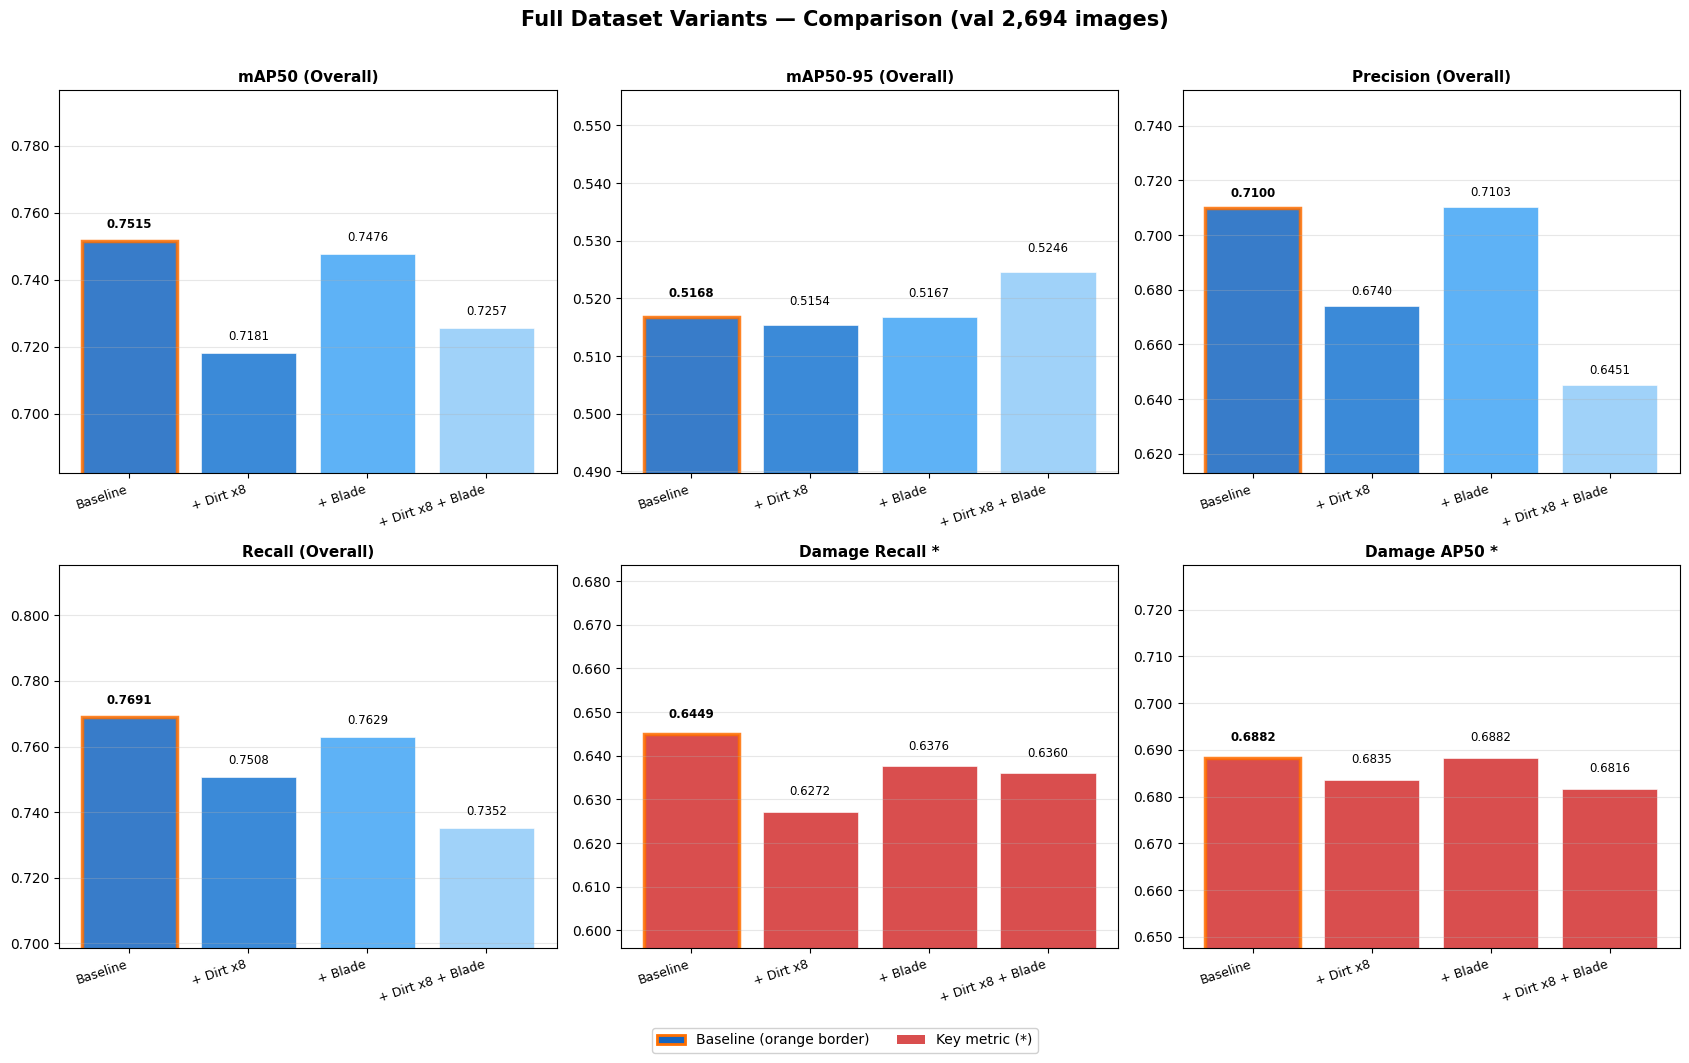

Saved -> ./outputs/phase5_full_comparison.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

labels  = ["Baseline", "+ Dirt x8", "+ Blade", "+ Dirt x8 + Blade"]
colors  = ["#1565C0", "#1976D2", "#42A5F5", "#90CAF9"]
baseline = 0

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Full Dataset Variants — Comparison (val 2,694 images)", fontsize=15, fontweight="bold", y=1.01)

metrics = [
    ("mAP50",         "mAP50 (Overall)",     axes[0, 0], None),
    ("mAP50-95",      "mAP50-95 (Overall)",  axes[0, 1], None),
    ("Precision",     "Precision (Overall)", axes[0, 2], None),
    ("Recall",        "Recall (Overall)",    axes[1, 0], None),
    ("Damage_Recall", "Damage Recall *",     axes[1, 1], "#D32F2F"),
    ("Damage_AP50",   "Damage AP50 *",       axes[1, 2], "#D32F2F"),
]

for metric, title, ax, accent in metrics:
    vals = [r[metric] for r in rows]
    bar_colors = [accent or colors[i] for i in range(len(vals))]
    bars = ax.bar(range(len(vals)), vals, color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)

    for i, (bar, v) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8.5,
                fontweight="bold" if i == baseline else "normal")

    bars[baseline].set_edgecolor("#FF6F00")
    bars[baseline].set_linewidth(2.5)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(min(vals) * 0.95, max(vals) * 1.06)
    ax.grid(axis="y", alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))

legend_handles = [
    mpatches.Patch(facecolor=colors[0], edgecolor="#FF6F00", linewidth=2, label="Baseline (orange border)"),
    mpatches.Patch(facecolor="#D32F2F", alpha=0.85, label="Key metric (*)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

plt.tight_layout()
plt.savefig("./outputs/phase5_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> ./outputs/phase5_full_comparison.png")


## Phase 5-2 — Validation Prediction Visualization

Display GT vs Pred images auto-saved during Phase 5 `model.val()` runs.  
Each batch tile shows ~32 val images with bounding boxes.

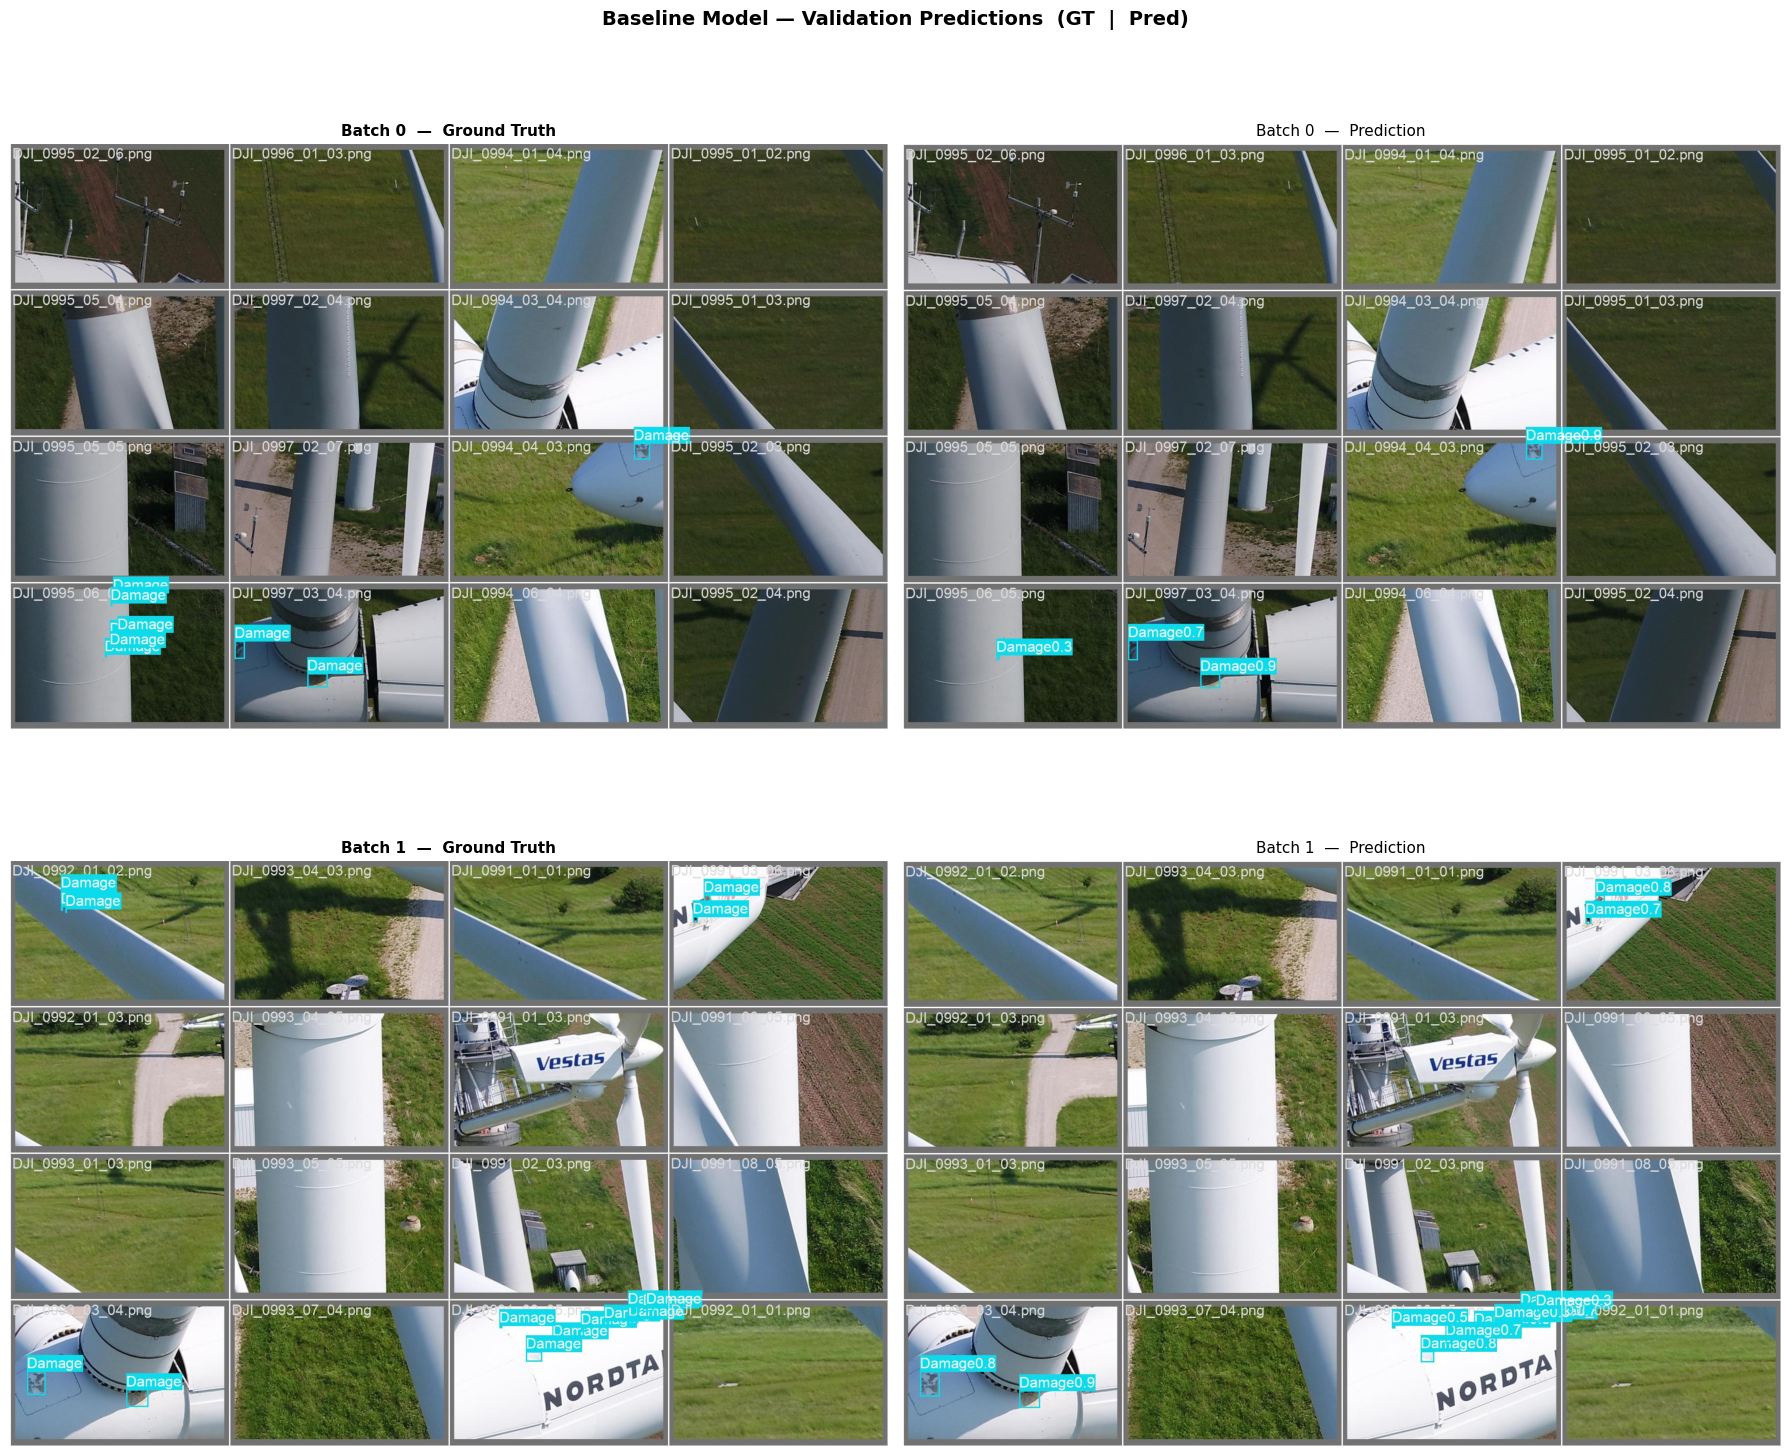

Saved -> ./outputs/phase52_baseline_predictions.png


In [18]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# 최종 선정 모델(Baseline)의 val 예측 이미지 표시
# val_batch*_labels.jpg = GT,  val_batch*_pred.jpg = Prediction
BASELINE = "exp_full_small_ep50"
save_dir  = val_save_dirs.get(BASELINE)

if save_dir is None or not save_dir.exists():
    print("Phase 5 셀을 먼저 실행하세요 (val_save_dirs 필요)")
else:
    BATCHES = [0, 1]   # 표시할 배치 인덱스 (0~2)

    fig, axes = plt.subplots(len(BATCHES), 2, figsize=(18, 8 * len(BATCHES)))
    fig.suptitle(f"Baseline Model — Validation Predictions  (GT  |  Pred)", fontsize=14, fontweight="bold")

    for row, b in enumerate(BATCHES):
        lbl_path  = save_dir / f"val_batch{b}_labels.jpg"
        pred_path = save_dir / f"val_batch{b}_pred.jpg"

        ax_l, ax_r = axes[row]

        if lbl_path.exists():
            ax_l.imshow(cv2.cvtColor(cv2.imread(str(lbl_path)), cv2.COLOR_BGR2RGB))
        ax_l.set_title(f"Batch {b}  —  Ground Truth", fontsize=11, fontweight="bold")
        ax_l.axis("off")

        if pred_path.exists():
            ax_r.imshow(cv2.cvtColor(cv2.imread(str(pred_path)), cv2.COLOR_BGR2RGB))
        ax_r.set_title(f"Batch {b}  —  Prediction", fontsize=11)
        ax_r.axis("off")

    plt.tight_layout()
    out_path = "./outputs/phase52_baseline_predictions.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")


## Phase 5-3 — Final Model: conf=0.2 vs default

Baseline(`exp_full_small_ep50`)에 conf threshold를 낮춰 Recall 향상 확인.
**최종 모델 = best.pt + conf=0.2**

In [19]:
# ══════════════════════════════════════════════════════════════════════════
# Phase 5-3 — conf=0.2 vs default(0.25) 비교
# 베이스라인 best.pt, 재학습 없이 추론 threshold만 조정
# ══════════════════════════════════════════════════════════════════════════
BASELINE = "exp_full_small_ep50"
pt = find_best_pt(BASELINE)

def eval_conf(conf_val):
    m = YOLO(str(pt)).val(data=YAML_FULL, device=EVAL_DEVICE,
                          conf=conf_val, verbose=False)
    idx = {int(c): i for i, c in enumerate(m.box.ap_class_index)}
    def cls(arr, cid):
        return round(float(arr[idx[cid]]), 4) if cid in idx else None
    return {
        "conf":          conf_val,
        "mAP50":         round(m.box.map50, 4),
        "mAP50-95":      round(m.box.map,   4),
        "Precision":     round(m.box.mp,    4),
        "Recall":        round(m.box.mr,    4),
        "Damage_Prec":   cls(m.box.p,    1),
        "Damage_Recall": cls(m.box.r,    1),
        "Damage_AP50":   cls(m.box.ap50, 1),
    }

results_conf = []
for c in [0.25, 0.20]:
    print(f"평가 중: conf={c} ...")
    r = eval_conf(c)
    results_conf.append(r)
    print(f"  Recall={r['Recall']}  Damage_Recall={r['Damage_Recall']}  Precision={r['Precision']}  mAP50={r['mAP50']}")
    torch.cuda.empty_cache()

df_conf = pd.DataFrame(results_conf)
print("\n" + "="*90)
print("  Final Model — conf threshold 비교 (Baseline: exp_full_small_ep50)")
print("="*90)
print(df_conf.to_string(index=False))

# 변화량 출력
d = {k: results_conf[1][k] - results_conf[0][k]
     for k in ["Precision", "Recall", "Damage_Recall", "Damage_AP50", "mAP50"]}
print("\n  conf 0.25 → 0.20  변화량:")
for k, v in d.items():
    arrow = "↑" if v > 0 else "↓"
    print(f"    {k:<15}: {arrow} {v:+.4f}")

print(f"\n★ 최종 모델: {BASELINE}/weights/best.pt  |  conf=0.20")


평가 중: conf=0.25 ...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA TITAN RTX, 24576MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 553.9±78.0 MB/s, size: 199.7 KB)
val: Scanning /home/jhyun/Root/VScode/AIFFEL/Hackathon/data/dataset_yolo_full/labels/val.cache... 2694 images, 2093 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2694/2694 1.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 169/169 12.2it/s 13.8s0.1s
                   all       2694       1890       0.71      0.769      0.702      0.496
Speed: 0.5ms preprocess, 2.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/jhyun/Root/VScode/AIFFEL/Hackathon/runs/detect/val-70
  Recall=0.7691  Damage_Recall=0.6449  Precision=0.71  mAP50=0.7016
평가 중: conf=0.2 ...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA TI